**Проект: Предсказание стоимости автомобилей**

**Описание проекта**

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение, чтобы привлечь новых клиентов. В нём можно будет узнать рыночную стоимость своего автомобиля.

Задача проекта: зная данные о технических характеристиках, комплектации и ценах других автомобилей, построить модель, которая умеет определять стоимость автомобиля.

Критерии, которые важны заказчику:
- качество предсказания;
- время обучения модели;
- время предсказания модели.





**Загрузим все необходимые библиотеки**

In [144]:
!pip install -q catboost
!pip install -q phik
!pip install --upgrade scikit-learn

In [145]:
# Импорт библиотек
# Общие
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# Для создания pipeline и кодировки
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Модели
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Метрика
from sklearn.metrics import mean_squared_error

random_state = 4

План выполнения проекта

- Загрузим датасет
- Осуществим первоначальное исследование датасета и предобработку данных: определим наличие пропусков, исследуем типы данных, возможные разночтения в написании значений признаков, проверим на дубли
- Выявим неинформативные признаки и удалим их
- Разделим датасет на тестовую и тренировочную выборки
- Напишем pipeline для подготовки данных и выполним его
- Выберем несколько алгоритмов для предсказания стоимости автомобиля
- Сравним алгоритмы по точности предсказания при помощи метрики RMSE, времени обучения и времени предсказания
- Сделаем выводы

**Шаг 1. Загрузка данных.**

Мы получаем один датасет от компании-заказчика, он содержит признаки автомобилей и target - цену продажи автомобиля, в дальнейшем его надо будет разделить на тренировочную и тестовую выборки.

Загружаем датасет

In [ ]:
# Загрузим датафрейм
try:
    dataframe = pd.read_csv("autos.csv")
except FileNotFoundError:
    try:
        dataframe = pd.read_csv("datasets/autos.csv")
    except FileNotFoundError:
        dataframe = pd.read_csv("https://code.s3.yandex.net/datasets/autos.csv")

Столбцы в датасете:

DateCrawled — дата скачивания анкеты из базы

VehicleType — тип автомобильного кузова

RegistrationYear — год регистрации автомобиля

Gearbox — тип коробки передач

Power — мощность (л. с.)

Model — модель автомобиля

Kilometer — пробег (км)

RegistrationMonth — месяц регистрации автомобиля

FuelType — тип топлива

Brand — марка автомобиля

Repaired — была машина в ремонте или нет

DateCreated — дата создания анкеты

NumberOfPictures — количество фотографий автомобиля

PostalCode — почтовый индекс владельца анкеты (пользователя)

LastSeen — дата последней активности пользователя

**Выводы**

Мы осуществили загрузку датасета

**Шаг 2. Предобработка данных.**

Исследуем датасет:

- визуально,

- получим информацию о них методом info(),

- изучим явные пропуски,

-  проверим на наличие неявных пропусков и разночтений в написании слов,

- проверим на наличие дублей


In [147]:
# Проверка на пропуски, отображение типов данных
display(dataframe.head())
display(dataframe.shape)
display(dataframe.info())

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


(354369, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

В датасете, имеющем 354369 строк и 16 столбцов, есть несколько явных пропусков в столбцах "VehicleType", "Gearbox", "Model", "FuelType", "Repaired", типы данных в порядке

Заполним пропуски категориальных признаков 

In [148]:
# Выделим колонки, содержащие категориальные переменные
category = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']
# Заполним пропуски в категориальных данных заглушкой'unknown'
dataframe[category] = dataframe[category].fillna('unknown')

Проверим столбцы с не-численными признаками на наличие неявных пропусков и разночтений в написании слов (кроме признаков DateCrawled, DateCreated, LastSeen - канидатов на удаление, которые могут иметь много разных значений)

In [149]:
# Проверка уникальных значений в каждом не-числовом столбце
non_numeric_cols = ["VehicleType", "Gearbox", "Model", "FuelType", "Brand", "Repaired"]

for col in non_numeric_cols:
    unique_values = dataframe[col].unique()
    print(f"Уникальные значения в столбце '{col}':")
    print(unique_values)
    print(f"Количество уникальных значений: {len(unique_values)}\n")

Уникальные значения в столбце 'VehicleType':
['unknown' 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon'
 'other']
Количество уникальных значений: 9

Уникальные значения в столбце 'Gearbox':
['manual' 'auto' 'unknown']
Количество уникальных значений: 3

Уникальные значения в столбце 'Model':
['golf' 'unknown' 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max'
 '3_reihe' 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco'
 '5er' 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse'
 'clio' 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 

In [150]:
# Заменим все вхождения "petrol" на "gasoline" в столбце "Fuel"
# dataframe['FuelType'] = dataframe['FuelType'].replace('petrol', 'gasoline')

# Заменим все вхождения "range_rover" на "rangerover" в столбце "Model"
dataframe['Model'] = dataframe['Model'].replace('range_rover', 'rangerover')


Удалим неинформативные признаки

Неинформативными признаками являются

DateCrawled - дата получения данных

DateCreated - дата создания объявления

RegistrationMonth - месяц регистрации

LastSeen - дата активности пользователя

NumberOfPictures - количество фотографий в объявлении (условно неинформативна, при взгляде с другой стороны, чем больше фотографий - тем больше доверия к пользователю и объявлению, но так как у нас много данных, мы пренебрежем этой информацией)

PostalCode - почтовый код региона, спорно, но уберем


In [151]:
dataframe = dataframe.drop(columns = ["DateCrawled", "RegistrationMonth", "DateCreated", "LastSeen", "NumberOfPictures", "PostalCode"])

Построим матрицу корреляции, чтобы убедиться, что у нас нет проблемы мультиколлинеарности

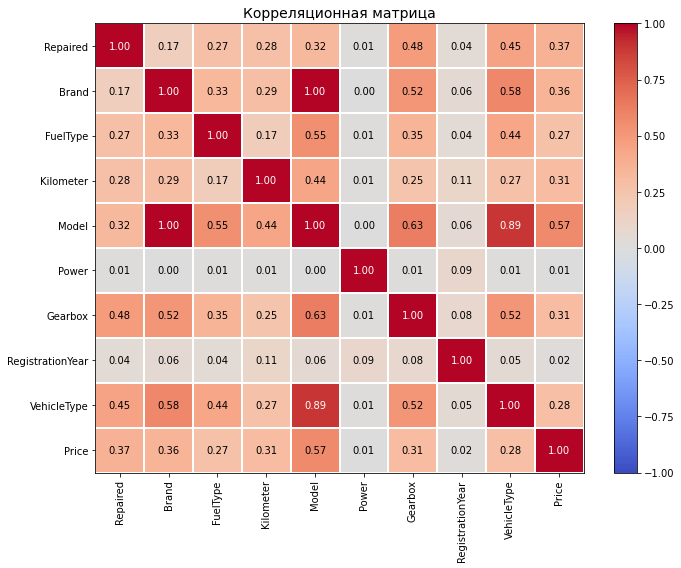

In [152]:
interval_cols = ["Price", "RegistrationYear", "Power", "Kilometer"]
phik_overview = phik_matrix(dataframe, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=-1, vmax=1, color_map='coolwarm',
    title=r'Корреляционная матрица',
    fontsize_factor=1,
    figsize=(10, 8),
)

Мы видим равную 1 корреляцию между брендом и моделью, а также близкую к единице корреляцию между моделью и типом транспортного средства, присутствует проблема мультиколлинеарности, мы удаляем избыточный столбец Model. 

In [153]:
dataframe = dataframe.drop(columns = ["Model"])

Проверим на дубликаты

In [154]:
dataframe.duplicated().sum()

52126

Удалим дубликаты

In [155]:
dataframe.drop_duplicates(inplace = True)

Исследуем аномальные показатели датасета при помощи метода describe()

In [156]:
dataframe.describe()

,Price,RegistrationYear,Power,Kilometer
count,302243.000000,302243.000000,302243.000000,302243.000000
mean,4526.891349,2004.408496,111.495062,126834.202943
std,4579.906957,93.613667,203.057581,38730.488635
min,0.000000,1000.000000,0.000000,5000.000000
25%,1100.000000,1999.000000,69.000000,125000.000000
50%,2800.000000,2003.000000,105.000000,150000.000000
75%,6500.000000,2008.000000,143.000000,150000.000000
max,20000.000000,9999.000000,20000.000000,150000.000000


В датасете обнаружены аномальные значения

*   Price 0 - ? (такое возможно)
*   RegistrationYear 1000, 9999
*   Power 0, 20000
   



Мы заменим аномальные значения несколькими способами:

- определим границы исходя из знаний о признаке в столбцах Year и Power
- удалим аномальные данные 


In [157]:
# Предположим, что самые старые автомобили будут 1980 г.
dataframe = dataframe.query('1980 <= RegistrationYear <= 2016')

# Используем данные о мощности двигателя: минимум возьмем 30 максимум 600 л.с. заполним медианой
dataframe = dataframe.query('30 <= Power <= 600')

Проанализируем аномалии столбца Price

In [158]:
# Посмотрим, какие объявления имеют 0 цену
dataframe.loc[dataframe["Price"] == 0]

,Price,VehicleType,RegistrationYear,Gearbox,Power,Kilometer,FuelType,Brand,Repaired
7,0,sedan,1980,manual,50,40000,petrol,volkswagen,no
152,0,bus,2004,manual,101,150000,lpg,opel,yes
231,0,wagon,2001,manual,115,150000,unknown,ford,unknown
466,0,unknown,2016,auto,197,150000,gasoline,bmw,no
524,0,unknown,2005,manual,136,100000,unknown,toyota,unknown
...,...,...,...,...,...,...,...,...,...
354175,0,unknown,1995,manual,45,150000,petrol,volkswagen,unknown
354205,0,unknown,2000,manual,65,150000,unknown,opel,yes
354238,0,small,2002,manual,60,150000,petrol,ford,unknown
354248,0,small,1999,manual,53,150000,petrol,suzuki,unknown


<AxesSubplot:>

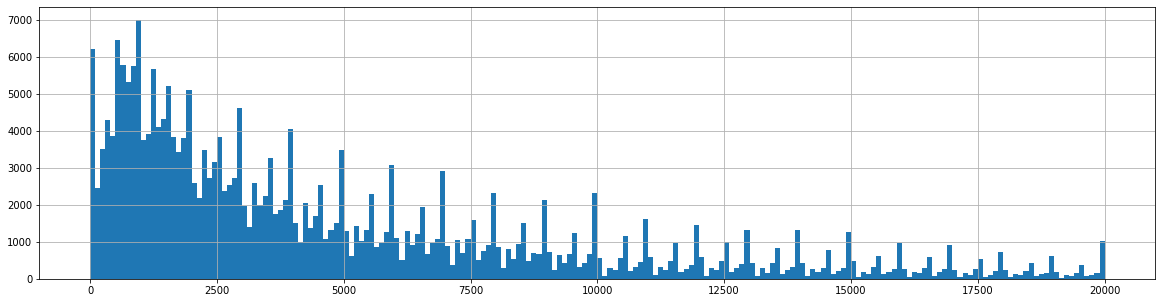

In [159]:
# Построим гистограму
dataframe['Price'].hist(bins=200, figsize=(20, 5))

Мы видим аномальные значение цен близкие или равные 0, отбросим совсем уж низкие цены менее 50.

In [160]:
dataframe = dataframe.query('50 <= Price')

**Выводы**

Мы осуществили предобработку данных: датасет оказался сложным для очистки, но большим, что позволяет избавляться от данных, которые могут ухудшить качество модели. 

- Обнаружили множество явных пропусков в столбцах "VehicleType", "Gearbox", "Model", "FuelType", "Repaired", типы данных в порядке и заполнили их "unknown"

- Обнаружили неявные дубликаты: разночтения в написании rangerover и разные названия одного вида топлива petrol/gasoline и заменили их

- Удалили неинформативные столбцы:"DateCrawled", "RegistrationMonth", "DateCreated", "LastSeen", "NumberOfPictures", "PostalCode" 

- Построили матрицу корреляций и увидели значительную корреляцию между столбцами "Model" и "Brand", также "Model" и "VehicleType", удалили значение  

- Удалили явные дубликаты 

- Удалили данные, содержащие аномальные значения в столбцах "Price", "RegistrationYear", "Power"

**Шаг 3. Разделим выборки на train, val и test**

Разделим данные на тренировочную, валидационную и тестовую выборку, на тренировочной выборке будем обучать модели, на валидационной оценивать, на тестовой тестировать лучшую модель. 

In [161]:
X = dataframe.drop(columns = ["Price"])
y = dataframe["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = random_state)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.25, random_state = random_state)

In [162]:
display(X_train.shape)
display(X_val.shape)
display(X_test.shape)

(149289, 8)

(49764, 8)

(49764, 8)

Используем StandardScaler для масштабирования данных

In [163]:
# Опрделим числовые, порядковые и категориальные признаки
numeric_cols = ["Power", "Kilometer", "RegistrationYear"]

In [164]:
# Pipeline для числовых признаков, в нашем случае нет пропусков, но для возможных пропусков используем заполнение медианой
numeric_pipe = Pipeline(steps=[
    ("StandardScaler", StandardScaler()),
]
)

# Единый pipeline preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("NumericPipe", numeric_pipe, numeric_cols),
], remainder = "passthrough", verbose_feature_names_out = False)

Осуществим обработку датасетов при помощи preprocessor пайплайна.

In [165]:
# Сохраним типы данных
original_dtypes_train = X_train.dtypes
original_dtypes_val = X_val.dtypes
original_dtypes_test = X_test.dtypes

# Обработка данных
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

# Получим имена столбцов и превратим массивы в датасеты
feature_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train, columns = feature_names)
X_train = X_train.astype(original_dtypes_train.to_dict())
X_val = pd.DataFrame(X_val, columns = feature_names)
X_val = X_val.astype(original_dtypes_val.to_dict())
X_test = pd.DataFrame(X_test, columns = feature_names)
X_test = X_test.astype(original_dtypes_test.to_dict())

In [166]:
X_train.head()

,Power,Kilometer,RegistrationYear,VehicleType,Gearbox,FuelType,Brand,Repaired
0,0,0,0,coupe,manual,petrol,bmw,no
1,0,0,0,bus,manual,gasoline,fiat,no
2,0,0,0,small,manual,gasoline,seat,no
3,0,0,1,wagon,auto,gasoline,volkswagen,no
4,0,0,0,small,manual,gasoline,peugeot,yes


In [167]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149289 entries, 0 to 149288
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Power             149289 non-null  int64 
 1   Kilometer         149289 non-null  int64 
 2   RegistrationYear  149289 non-null  int64 
 3   VehicleType       149289 non-null  object
 4   Gearbox           149289 non-null  object
 5   FuelType          149289 non-null  object
 6   Brand             149289 non-null  object
 7   Repaired          149289 non-null  object
dtypes: int64(3), object(5)
memory usage: 9.1+ MB


**Выводы**

Мы разделили датасет на train, val и test, обработали выборки pipeline c инструментом масштабирования StandardScaler(), что необходимо для модели линейной регрессии. 

**Шаг 4. Обучение моделей.**

План действий на этапе обучения моделей:

- метрикой оценки будет RMSE - квадратный корень из средней квадратичной ошибки

- отследим параметры времени обучения и предсказания

- выберем алгоритмы для применения: Linear Redression, CatboostRegressor, LightGBMRegressor



Linear Regression

Для линейной регрессии необходимо кодировать признаки категориальные признаки, используем OneHotEncoder



In [168]:
# Выделим колонки, содержащие категориальные переменные
# Исключим модели
category = ['VehicleType', 'Gearbox', 'FuelType', 'Brand', 'Repaired']

X_train_ohe = X_train.copy()
X_val_ohe = X_val.copy()
X_test_ohe = X_test.copy()

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# обучим и сразу закодируем кат. признаки трейна
train_encoded = encoder.fit_transform(X_train_ohe[category])

# добавим в трейн кодированные признаки и удалим исходные
X_train_ohe[encoder.get_feature_names_out()] = train_encoded
X_train_ohe.drop(category, axis=1, inplace=True)

# все аналогичные шаги кроме обучения кодировщика для валидационной тестовой выборки
val_encoded = encoder.fit_transform(X_val_ohe[category])
X_val_ohe[encoder.get_feature_names_out()] = val_encoded
X_val_ohe.drop(category, axis=1, inplace=True)

test_encoded = encoder.transform(X_test_ohe[category])
X_test_ohe[encoder.get_feature_names_out()] = test_encoded
X_test_ohe.drop(category, axis=1, inplace=True)

In [169]:
%%time
#модель линейной регрессии
model_lr = LinearRegression() 
model_lr.fit(X_train_ohe, y_train)

CPU times: user 1.55 s, sys: 1.03 s, total: 2.58 s
Wall time: 2.55 s


LinearRegression()

In [170]:
%%time
y_predict = model_lr.predict(X_val_ohe)
rmse_linear = mean_squared_error(y_val, y_predict)**0.5
print("RMSE линейной регрессии: ", rmse_linear)

RMSE линейной регрессии:  3116.0459695028867
CPU times: user 27.3 ms, sys: 35.2 ms, total: 62.5 ms
Wall time: 22.8 ms


CatBosstRegressor, алгоритм сам кодирует категориальные признаки

In [171]:
category = ["VehicleType", "Gearbox", "FuelType", "Brand", "Repaired"]
model_cat = CatBoostRegressor(random_state=random_state, cat_features=category, verbose=False)
parameters = {
    'learning_rate': [0.1, 0.5, 0.8],
    'iterations': [10, 20, 30]
}
grid_cat = GridSearchCV(model_cat,
                        parameters,
                        scoring='neg_mean_squared_error')

grid_cat.fit(X_train, y_train)
grid_cat.best_params_

{'iterations': 30, 'learning_rate': 0.8}

In [172]:
%%time
model_cat = CatBoostRegressor(iterations = 30, learning_rate = 0.8, random_state=random_state, cat_features=category, verbose=False)
model_cat.fit(X_train, y_train)

CPU times: user 2.04 s, sys: 20.4 ms, total: 2.06 s
Wall time: 2.58 s


In [173]:
%%time
y_predict = model_cat.predict(X_val)
rmse_cat = mean_squared_error(y_val, y_predict) ** 0.5
print('RMSE CatBoost', rmse_cat)

RMSE CatBoost 2552.758962137049
CPU times: user 66.2 ms, sys: 3.83 ms, total: 70 ms
Wall time: 71.4 ms


LightGBM, нужно закодировать категориальные признаки

In [174]:
# закодируем категориальные признаки 
ordinal_enc = OrdinalEncoder()

X_train_category = ordinal_enc.fit_transform(X_train[category])
X_train[category] = X_train_category

X_val_category = ordinal_enc.transform(X_val[category])
X_val[category] = X_val_category

X_test_category = ordinal_enc.transform(X_test[category])
X_test[category] = X_test_category

In [176]:
model_lgbm = LGBMRegressor(random_state=random_state, verbose = 0)

parameters = {
       'learning_rate': [0.1, 0.2, 0.4],
        'num_leaves': [10, 14, 20]
}
grid_lgbm = GridSearchCV(model_lgbm,
                        parameters)

grid_lgbm.fit(X_train, y_train)
grid_lgbm.best_params_

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.313327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.317034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing

{'learning_rate': 0.4, 'num_leaves': 20}

In [177]:
%%time 
model_lgbm = LGBMRegressor(learning_rate = 0.4, num_leaves = 20, random_state=random_state, verbose = 0)
model_lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.495765 seconds.
You can set `force_col_wise=true` to remove the overhead.
CPU times: user 1min 42s, sys: 1.18 s, total: 1min 44s
Wall time: 1min 45s


LGBMRegressor(learning_rate=0.4, num_leaves=20, random_state=4, verbose=0)

In [178]:
%%time
y_predict = model_lgbm.predict(X_val)
rmse_lgbm = mean_squared_error(y_val, y_predict) ** 0.5
print('RMSE LightGBM', rmse_lgbm)

RMSE LightGBM 2480.1755965270686
CPU times: user 316 ms, sys: 0 ns, total: 316 ms
Wall time: 307 ms


Сравнение моделей

In [179]:
df = [["2.55 s", "22.8 ms", 3116.05],
        ["2.58 s", "71.4 ms", 2552.76],
        ["1min 45s", "307 ms", 2480.18]]
model = ["LinearRegression", "CatBoostRegressor", "LGBMRegressor"]
pd.DataFrame(data=df, index=model, columns=["Время обучения WALL TIME", "Время предсказания WALL TIME", "RMSE"])

,Время обучения WALL TIME,Время предсказания WALL TIME,RMSE
LinearRegression,2.55 s,22.8 ms,3116.05
CatBoostRegressor,2.58 s,71.4 ms,2552.76
LGBMRegressor,1min 45s,307 ms,2480.18


**Выводы**:
Мы обработали данные и осуществили предсказание цены автомобиля моделями LinearRegression, CatBoostRegressor, LightGBMRegressor.

Мы сравнили результаты по времени обучения и предсказания и точности предсказания при помощи метрики RMSE.

Точнее всего сработал алгоритм LightGBMRegressor, самым быстрым в обучении и предсказании оказался LinearRegression, достаточно быстрым и точным - CatBoostRegressor, он почти достиг качества LightGBMRegressor по метрике точности. 

В качестве лучшей модели выбираем модель LightGBMRegressor. 

 **Шаг 5. Тестирование лучшей модели**
 
 Мы протестируем лучшую модель - LightGBMRegressor - на тестовой выборке 

In [184]:
y_predict = model_lgbm.predict(X_test)
rmse_lgbm = mean_squared_error(y_test, y_predict) ** 0.5
print('RMSE LGBM', rmse_lgbm)

RMSE LGBM 2483.036612032582


**Вывод** На тестовой выборке LightGBMRegressor проявил себя так же, как на валидационной, RMSE = 2483.04

**Общий вывод**

Мы изучили очень большой датасет, описывающий признаки автомобилей, выставленных на продажу. 

В датасете было много пропусков в категориальных признаках, их заполнили "unknown". 
Неинформативные столбцы были удалены. 
Дубли были удалены. 
В датасете было много аномальных значений, данные с ними были удалены

Датасет был разделен на train, val и test выборки, данные были обработаны StandardScaler. 

Были выбраны три модели - LinearRegression, CatBoostRegressor и LGBMRegressor, для них были подобраны гиперпараметры, 
на выборке train было измерено время обучения, на выборке val - время предсказания и метрика RMSE. 

Лучшей оказалась модель LGBMRegressor, которая была протестирована на выборке test. 
